<a href="https://colab.research.google.com/github/wesnasimone/IA025_Introducao_Aprendizado_Profundo/blob/main/(2026S2)_Exerc%C3%ADcio_Classifica%C3%A7%C3%A3o_de_imagens_com_CNNs_Wesna_225843.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IA025 - Exercício: Classificação de imagens com **CNNs**


## Coloque seu nome

In [ ]:
# TODO: imprima o seu nome completo
print("Wesna Simone Bulla de Araujo")

Wesna Simone Bulla de Araujo


In [ ]:
!pip install pytorch_lightning torchmetrics -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 852.4/852.4 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 54.9 MB/s eta 0:00:00


# Convoluções


In [ ]:
from skimage import data
import matplotlib.pyplot as plt
import numpy as np

cat = data.cat()
cat.shape

(300, 451, 3)

(300, 451)


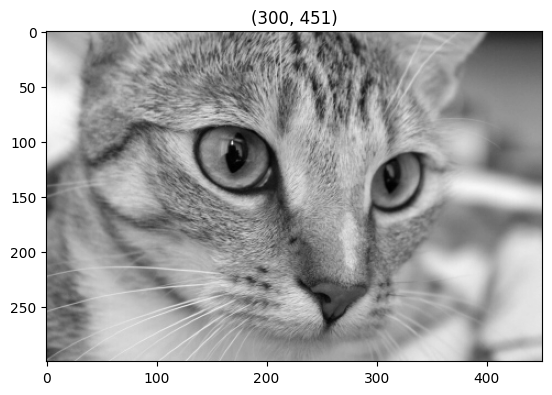

In [ ]:
old_cat = cat.mean(axis=-1)
print(old_cat.shape)

plt.title(old_cat.shape)
plt.imshow(old_cat, cmap="gray")
plt.show()

In [ ]:
# Kernel 3x3
conv_kernel = np.array([[-1, -1, -1],
                        [0, 0, 0],
                        [1, 1, 1]])

# Perdemos uma linha e uma coluna de cada lado pelo tamanho do kernel
output = np.zeros((old_cat.shape[0] - 2, old_cat.shape[1] - 2))

# i = row, j = col for output features
for i in range(output.shape[0]):
    for j in range(output.shape[1]):
        # k = kernel row, l = kernel col
        for k in range(conv_kernel.shape[0]):
            for l in range(conv_kernel.shape[1]):
                output[i, j] += old_cat[i + k, j + l] * conv_kernel[k, l]

Como transformar em somente 2 loops python?

In [ ]:
# Kernel 3x3
conv_kernel = np.array([[-1, -1, -1],
                        [0, 0, 0],
                        [1, 1, 1]])

# Perdemos uma linha e uma coluna de cada lado pelo tamanho do kernel
output = np.zeros((old_cat.shape[0] - 2, old_cat.shape[1] - 2))

# i = row, j = col for output features
for i in range(output.shape[0]):
    for j in range(output.shape[1]):
        # k = kernel row, l = kernel col
        output[i, j] = np.sum(old_cat[i:i+3, j:j+3] * conv_kernel)

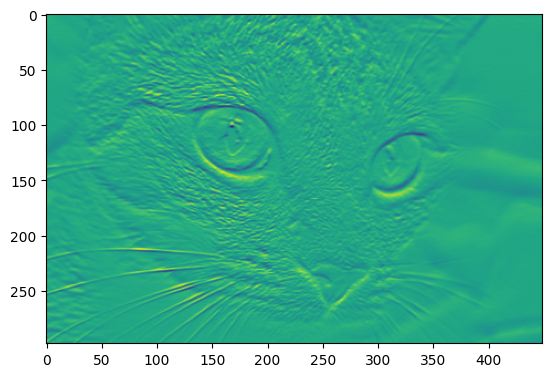

In [ ]:
plt.imshow(output)

Como implementar de forma otimizada no PyTorch?

In [ ]:
import torch
import random
# Formato numpy [Rows, Cols, Channels]
# Formato PyTorch [Batch, Channels, Rows, Cols]
cat_tensor = torch.from_numpy(cat).float().permute(2, 0, 1).unsqueeze(0)
cat_tensor = torch.nn.functional.interpolate(cat_tensor, size=(64, 64))

# cat_tensor.shape

In [ ]:
# Nosso kernel agora são parâmetros!
conv_kernel_weights = torch.nn.Parameter(torch.randn(1, 3, 3, 3), requires_grad=True)

conv_kernel_weights, conv_kernel_weights.shape

(Parameter containing:
 tensor([[[[ 1.1406, -1.7416,  0.6416],
           [ 1.4243,  0.2833,  0.9724],
           [-0.4937, -2.3943,  0.8543]],
 
          [[ 1.1761,  0.0831,  0.6279],
           [ 2.6787,  2.1827, -0.2553],
           [-0.0099, -0.7349,  1.2999]],
 
          [[-0.7103,  0.7461, -0.5822],
           [-0.1431, -0.6732, -0.4468],
           [ 1.7034,  0.7551, -0.4505]]]], requires_grad=True),
 torch.Size([1, 3, 3, 3]))

In [ ]:
kernel_height = 3
kernel_width = 3

# O F.unfold extrai blocos de tamanho (3 * 3 * 3 = 27) para cada posição espacial que o kernel irá "passar"
patches_3d = torch.nn.functional.unfold(cat_tensor, kernel_size=(kernel_height, kernel_width))

patches_3d.shape, 62*62

(torch.Size([1, 27, 3844]), 3844)

In [ ]:
# Casamos a multiplicação de matriz pelo tamanho do patch!
conv_kernel_weights_flat = conv_kernel_weights.view(1, -1)

conv_kernel_weights_flat, conv_kernel_weights_flat.shape

(tensor([[ 1.1406, -1.7416,  0.6416,  1.4243,  0.2833,  0.9724, -0.4937, -2.3943,
           0.8543,  1.1761,  0.0831,  0.6279,  2.6787,  2.1827, -0.2553, -0.0099,
          -0.7349,  1.2999, -0.7103,  0.7461, -0.5822, -0.1431, -0.6732, -0.4468,
           1.7034,  0.7551, -0.4505]], grad_fn=<ViewBackward0>),
 torch.Size([1, 27]))

In [ ]:
# Mágica:

# Multiplicação de matriz executa im2col + GEMM do slide
out_matmul = torch.matmul(conv_kernel_weights_flat, patches_3d)
out_matmul.shape, out_matmul.grad

/tmp/ipykernel_1194/1175943714.py:5: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more information. (Triggered internally at /pytorch/build/aten/src/ATen/core/TensorBody.h:494.)
  out_matmul.shape, out_matmul.grad


(torch.Size([1, 1, 3844]), None)

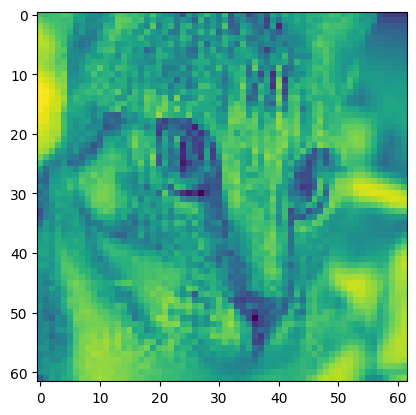

In [ ]:
# Voltando para o formato de imagem 2D:
out_final = out_matmul.view(1, 1, 62, 62)
plt.imshow(out_final.squeeze().detach())

In [ ]:
# Podemos calcular o gradiente dos pesos da convolução!
fake_loss = torch.sum(out_final)
fake_loss.backward()

conv_kernel_weights.grad

tensor([[[[565701., 565380., 565085.],
          [566908., 566791., 566672.],
          [568430., 568517., 568554.]],

         [[424071., 423999., 424058.],
          [425535., 425670., 425924.],
          [427300., 427648., 428070.]],

         [[326280., 326648., 327242.],
          [327826., 328418., 329229.],
          [329698., 330532., 331531.]]]])

torch.Size([10, 27, 3844])


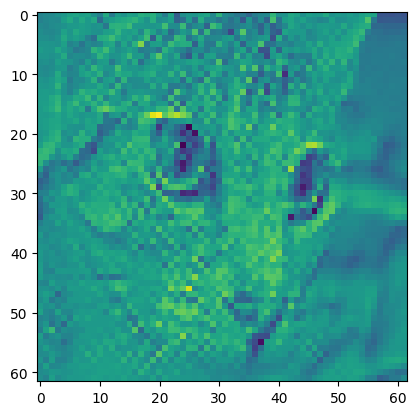

In [ ]:
# Em caso de o tensor ser um batch de imagens, o CUDA irá paralelizar a multiplicação automaticamente.
batch_patches_3d = torch.nn.functional.unfold(torch.cat([cat_tensor]*10), kernel_size=(kernel_height, kernel_width))

print(batch_patches_3d.shape)

# Basta aumentar o número de filtros para termos mais parâmetros apredidos, criando mapas de features com mais canais, essencial para CNNs.
# A operação otimizada ainda funciona sem loops mesmo com batches de imagens e múltiplos kernels.
ten_conv_kernel_weights = torch.nn.Parameter(torch.randn(10, 3, 3, 3))
ten_conv_kernel_weights_flat = ten_conv_kernel_weights.view(10, -1)

out_batched_matmul = torch.matmul(ten_conv_kernel_weights_flat, batch_patches_3d)
out_final = out_batched_matmul.view(10, 10, 62, 62)

# Agora só conseguimos visualizar a saida de um item do batch em um canal específico
plt.imshow(out_final[random.randint(0, 9)][random.randint(0, 9)].detach())


## A quick MNIST CNN

In [ ]:
import os
import pytorch_lightning as pl
import torchmetrics
import torch
from torchvision.transforms import ToTensor
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader

class MNISTDataModule(pl.LightningDataModule):
    def __init__(self):
        super().__init__()

    def setup(self, stage=None):
        self.train_ds = MNIST(os.getcwd(), train=True, download=True, transform=ToTensor())
        self.val_ds = MNIST(os.getcwd(), train=False, download=True, transform=ToTensor())

    def train_dataloader(self):
        return DataLoader(self.train_ds, batch_size=32)

    def val_dataloader(self):
        return DataLoader(self.val_ds, batch_size=32)

class MNISTCNN(pl.LightningModule):
    def __init__(self):
        super().__init__()

        # First layer
        self.conv1 = torch.nn.Conv2d(in_channels=1, out_channels=8, kernel_size=(7, 7), stride=1, padding=3)
        self.norm1 = torch.nn.BatchNorm2d(8)
        self.relu1 = torch.nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        # Qual resolução das features aqui?

        # Second layer
        self.conv2 = torch.nn.Conv2d(in_channels=8, out_channels=32, kernel_size=(3, 3), stride=1, padding=1)
        self.norm2 = torch.nn.BatchNorm2d(32)
        self.relu2 = torch.nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=2)
        # Qual resolução das features aqui?

        # Global Average Pooling
        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))

        # FC
        self.fc1 = torch.nn.Linear(in_features=32, out_features=10)

        # Loss and metric
        self.loss_fn = torch.nn.CrossEntropyLoss()
        self.acc = torchmetrics.Accuracy(task="multiclass", num_classes=10)


    def forward(self, x):
        # Convolutional layers store intermediate features on x
        x = self.conv1(x)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        x = self.gap(x)

        # Flatten features  for final classification
        x = x.view(x.size(0), -1)
        x = self.fc1(x)

        return x

    def step(self, batch, batch_idx, phase):
        x, y = batch
        logits = self(x)
        loss = self.loss_fn(logits, y)
        self.log(f"{phase}_loss", loss, prog_bar=True)
        self.log(f"{phase}_acc", self.acc(logits, y), prog_bar=True)
        return loss

    def training_step(self, batch, batch_idx):
        return self.step(batch, batch_idx, "train")

    def validation_step(self, batch, batch_idx):
        self.step(batch, batch_idx, "val")

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=0.01)

module = MNISTCNN()
datamodule = MNISTDataModule()
pl.Trainer(max_epochs=10).fit(module, datamodule)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
100%|██████████| 9.91M/9.91M [00:00<00:00, 58.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.69MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.9MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 18.4MB/s]
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name    ┃ Type               ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ conv1   │ Conv2d             │    400 │ train │     0 │
│ 1  │ norm1   │ BatchNorm2d        │     16 │ train │     0 │
│ 2  │ relu1   │ ReLU               │      0 │ train │     0 │
│ 3  │ pool1   │ MaxPool2d          │      0 │ train │     0 │
│ 4  │ conv2   │ Conv2d             │  2.3 K │ train │     0 │
│ 5  │ norm2   │ BatchNorm2d        │     64 │ train │     0 │
│ 6  │ relu2   │ ReLU               │      0 │ train │     0 │
│ 7  │ pool2   │ MaxPool2d          │      0 │ train │     0 │
│ 8  │ gap     │ AdaptiveAvgPool2d  │      0 │ train │     0 │
│ 9  │ fc1     │ Linear             │    330 │ train │     0 │
│ 10 │ loss_fn │ CrossEntropyLoss   │      0 │ train │     0 │
│ 11 │ acc     │ MulticlassAccuracy │      0 │ train │     0 │
└────┴─────────┴────────────────────┴────────┴───────┴───────┘

Trainable params: 3.1 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 3.1 K                                                                                                
Total estimated model params size (MB): 0.013                                                                      
Modules in train mode: 12                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.13/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)`
is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


## Visualização dos pesos aprendidos

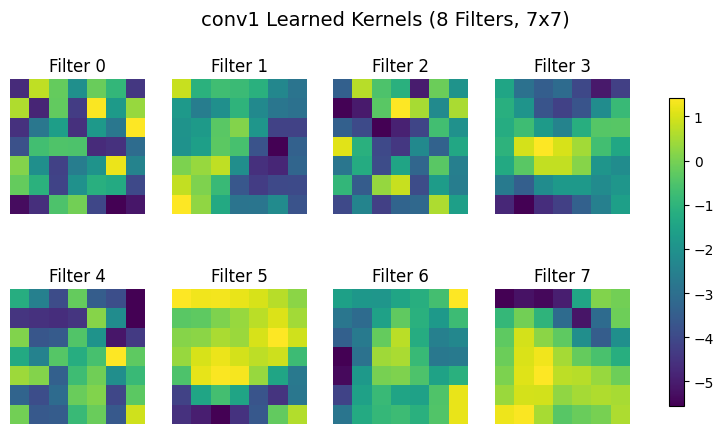

In [ ]:
import matplotlib.pyplot as plt

# Extract weights from conv1: shape is [8, 1, 7, 7]
conv1_weights = module.conv1.weight.detach().cpu()

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
fig.suptitle("conv1 Learned Kernels (8 Filters, 7x7)", fontsize=14)

for i, ax in enumerate(axes.flat):
    # Select the i-th filter and squeeze the channel dimension -> [7, 7]
    kernel = conv1_weights[i, 0]

    im = ax.imshow(kernel, cmap="viridis")
    ax.set_title(f"Filter {i}")
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8)
plt.show()

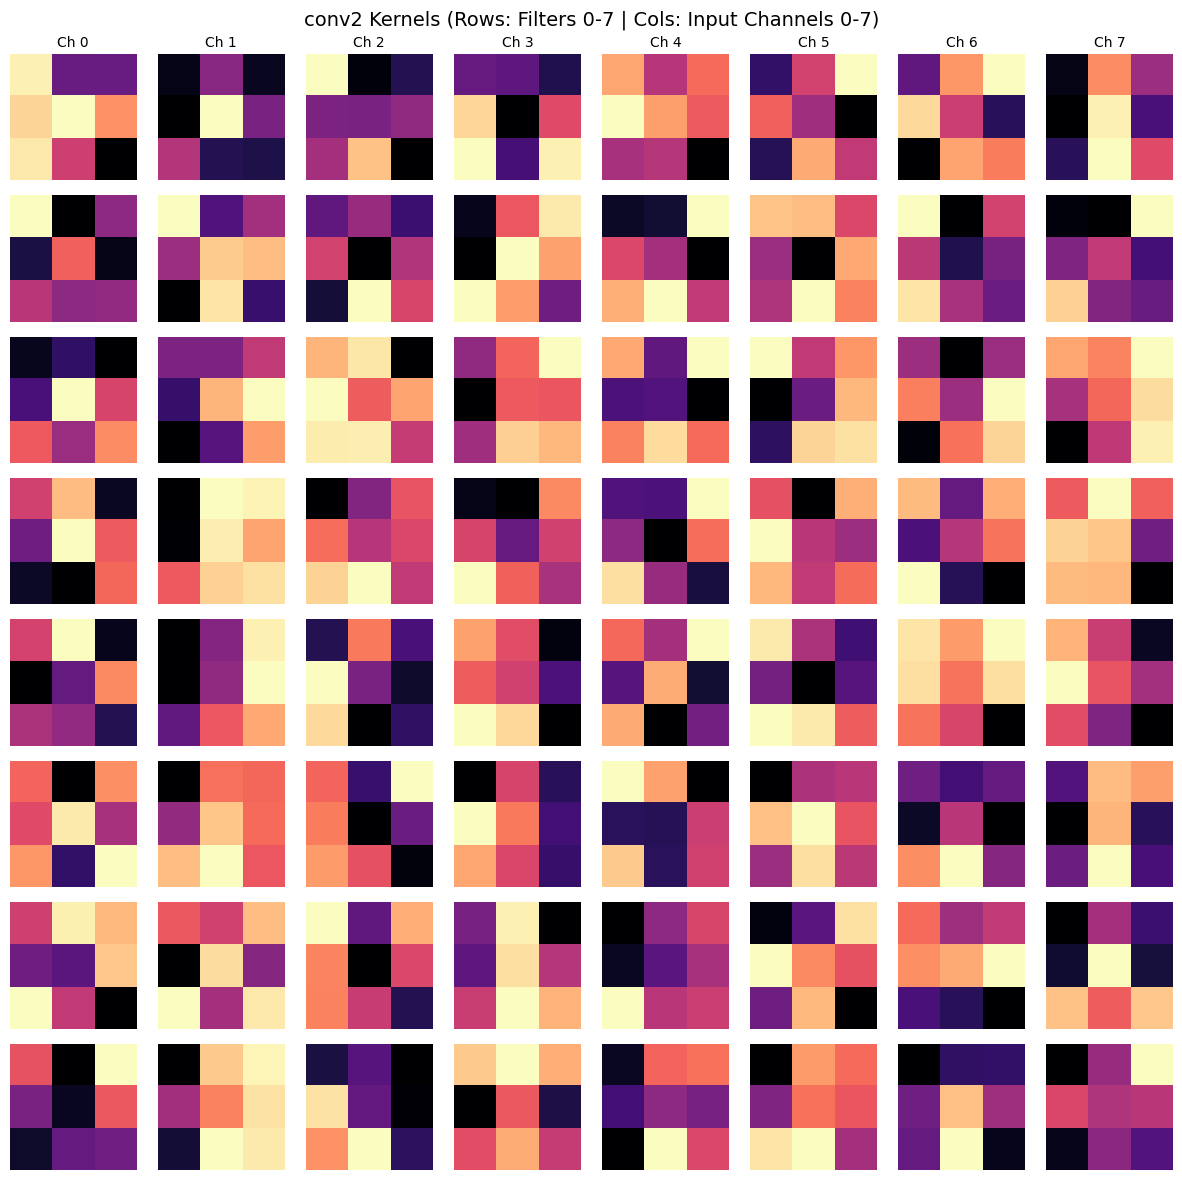

In [ ]:
# Extract weights from conv2: shape is [32, 8, 3, 3]
conv2_weights = module.conv2.weight.detach().cpu()

# Visualize the first 8 filters across all 8 input channels
fig, axes = plt.subplots(8, 8, figsize=(12, 12))
fig.suptitle("conv2 Kernels (Rows: Filters 0-7 | Cols: Input Channels 0-7)", fontsize=14)

for filter_idx in range(8):
    for channel_idx in range(8):
        ax = axes[filter_idx, channel_idx]
        kernel = conv2_weights[filter_idx, channel_idx]

        ax.imshow(kernel, cmap="magma")
        ax.axis("off")

        if filter_idx == 0:
            ax.set_title(f"Ch {channel_idx}", fontsize=10)
        if channel_idx == 0:
            ax.set_ylabel(f"Filt {filter_idx}", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
val_loader = iter(datamodule.val_dataloader())

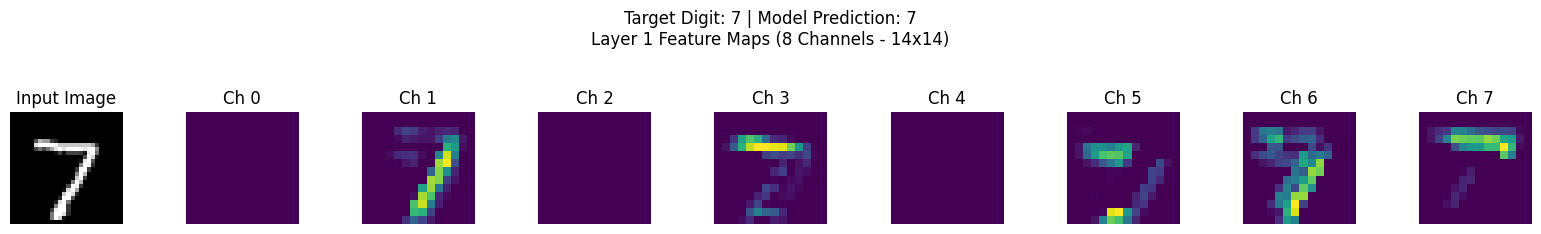

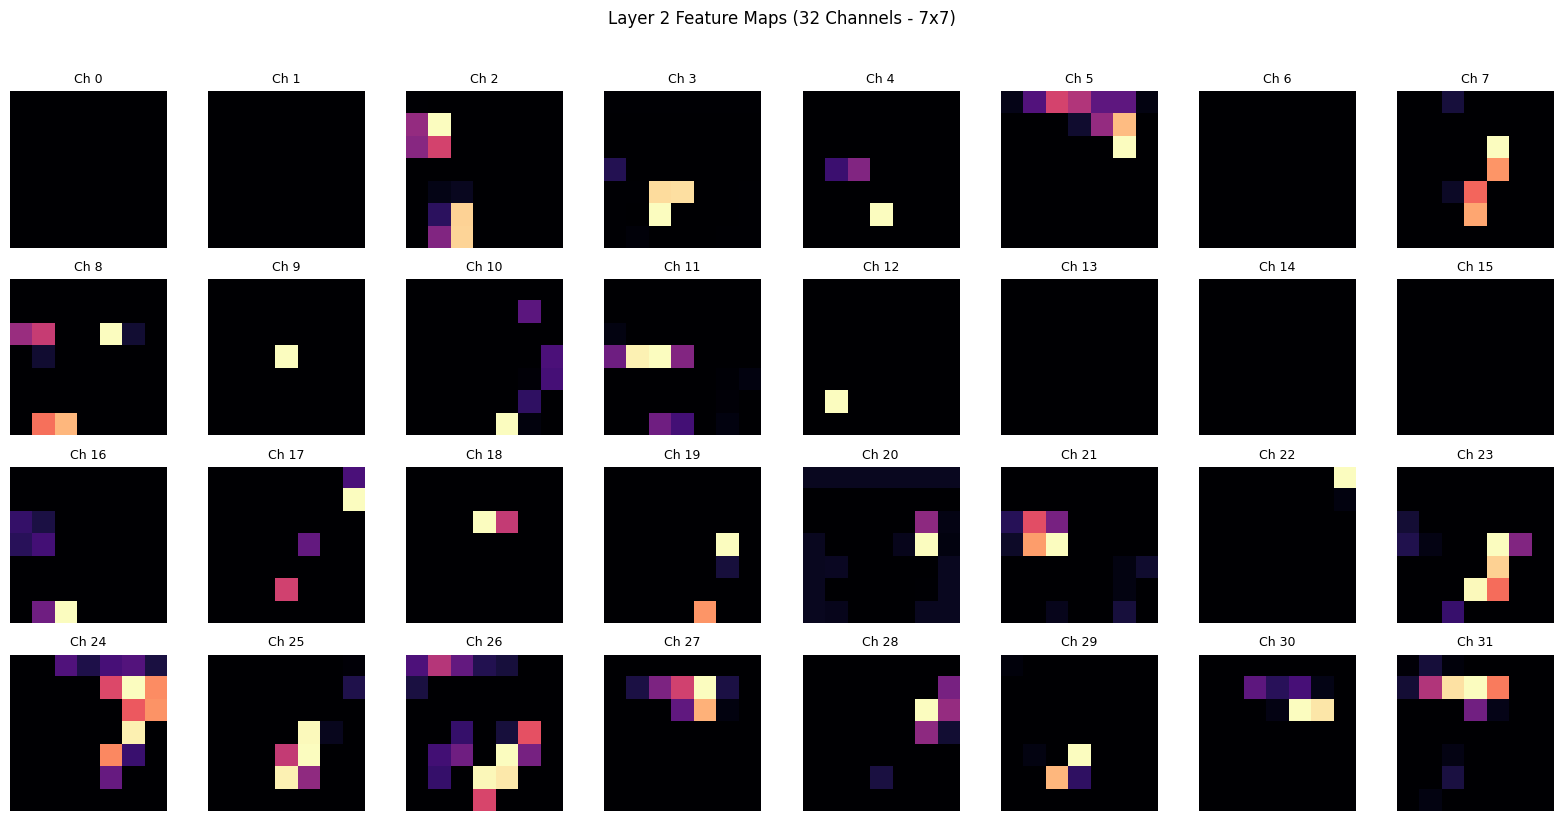

In [ ]:
import matplotlib.pyplot as plt
import torch

# 1. Select a single sample from the validation dataloader
x_batch, y_batch = next(val_loader)

# Take the first image and label from the batch
x_img = x_batch[0:1]  # Shape: [1, 1, 28, 28]
y_label = y_batch[0].item()

# 2. Extract intermediate feature maps during the forward pass
module.eval()
with torch.no_grad():
    # Layer 1
    f1_conv = module.conv1(x_img)
    f1_relu = module.relu1(f1_conv)
    f1_pool = module.pool1(f1_relu)  # Shape: [1, 8, 14, 14]

    # Layer 2
    f2_conv = module.conv2(f1_pool)
    f2_relu = module.relu2(f2_conv)
    f2_pool = module.pool2(f2_relu)  # Shape: [1, 32, 7, 7]

    # Output prediction
    logits = module(x_img)
    pred_label = logits.argmax(dim=1).item()

# 3. Plotting Layer 1 Feature Maps (8 Channels)
fig, axes = plt.subplots(1, 9, figsize=(16, 2))
fig.suptitle(
    f"Target Digit: {y_label} | Model Prediction: {pred_label}\nLayer 1 Feature Maps (8 Channels - 14x14)",
    fontsize=12,
    y=1.15,
)

# Original Input Image
axes[0].imshow(x_img.squeeze().numpy(), cmap="gray")
axes[0].set_title("Input Image")
axes[0].axis("off")

# 8 Feature Maps after Conv1 + ReLU + Pool1
for i in range(8):
    axes[i + 1].imshow(f1_pool[0, i].numpy(), cmap="viridis")
    axes[i + 1].set_title(f"Ch {i}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

# 4. Plotting Layer 2 Feature Maps (32 Channels - Grid 4x8)
fig, axes = plt.subplots(4, 8, figsize=(16, 8))
fig.suptitle(
    "Layer 2 Feature Maps (32 Channels - 7x7)", fontsize=12, y=1.02
)

for i, ax in enumerate(axes.flat):
    ax.imshow(f2_pool[0, i].numpy(), cmap="magma")
    ax.set_title(f"Ch {i}", fontsize=9)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Exercício
Enunciado: continuamos evoluindo a partir do exercício anterior. Agora, vamos mudar a nossa arquitetura para uma CNN e focar em melhorar o resultado no CIFAR-10.

* Continue utilizando a sua implementação da CrossEntropyLoss como função de perda. Ajuste se houve algum problema no outro exercício.
* Continue utilizando o loop de treino sem a classe Trainer do PyTorch Lightning.
* Agora, sua arquitetura deve ser uma rede convolucional construida por você (MyCNN).
* Além disso a operação de convolução 2D deve ser implementada por você (use nn.Conv2D para checar se está correta).

**DESAFIO:** Crie a classe do dataset TinyImageNet e treine sua rede convolucional nele também. Não utilize implementações do dataset do Hugging Face ou Torchvision.

Não se esqueça de trocar o ambiente de execução do notebook para usar GPUs quando tiver certeza que tudo está funcionando!


In [ ]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchmetrics import Accuracy

In [ ]:
# Um dicionário de hiperparâmetros é uma forma de organizar parâmetros do seu experimento.
# Você pode adicionar mais parâmetros, experimente muda-los!
hyperparameters = {
    "batch_size": 32,
    "learning_rate": 0.001,
    "kernel_size1": 7,  # exemplo de hiperparâmetro para CNN customizada
    "kernel_size2": 3,  # exemplo de hiperparâmetro para CNN customizada
    "nin": 3, # exemplo para entrada com 3 canais RGB
    "nout": 10,  # exemplo para 10 classes de saída
    "nkernel1": 8, # exemplo para numero de kernels na primeira camada convolucional
    "nkernel2": 32, # exemplo para numero de kernels na segunda camada convolucional
    "padding": 3,
    "stride": 2
}

In [ ]:
import torch
import torch.nn as nn

class MyConv2d(torch.nn.Module):
    """
    Implemente a convolução 2D de forma otimizada, com multiplicação de matriz e im2col (torch unfold)
    """
    def __init__(self, nin, nkernel, kernel_size, padding=1, stride=1, bias=True):
        super().__init__()
        self.nin = nin
        self.nkernel = nkernel
        self.kernel_size = kernel_size
        self.bias = bias
        self.padding = padding
        self.stride = stride

        #foi necessario multiplicar os pesos por um valor pequeno para evitar que o gradiente ficasse muito grande
        self.weight = nn.Parameter(torch.randn((self.nkernel, self.nin, self.kernel_size, self.kernel_size), requires_grad=True)*0.1) #variavel treinavel durante o treinamento
        self.b = nn.Parameter(torch.randn((1, nkernel, 1), requires_grad=True))

    def forward(self, input_tensor):

      #determina novas dimensões do feature map
      B, _, H, W = input_tensor.shape
      Hout = ((H + 2*self.padding - self.kernel_size) // self.stride) + 1
      Wout = ((W + 2*self.padding - self.kernel_size) // self.stride) + 1

      #cria matriz de convolução e matrizes de pesos
      patches_3d = torch.nn.functional.unfold(input_tensor, kernel_size=(self.kernel_size, self.kernel_size), padding=self.padding, stride=self.stride)
      conv_kernel_weights_flat = self.weight.view(self.nkernel, -1)

      #realiza a convolução
      out_batched_matmul = torch.matmul(conv_kernel_weights_flat, patches_3d)

      #soma o bias se desejado
      if self.bias == True:
         out_batched_matmul = out_batched_matmul + self.b

      #a entrada tem que voltar para o formato separado [B, C, H, W]
      out_final = out_batched_matmul.view(B, self.nkernel, Hout, Wout)

      return out_final

class MyCNN(torch.nn.Module):
    """
    Crie uma CNN com múltiplas camadas.
    Lembre se de aumentar o número de canais para possibilitar a criação de features ricas.
    Utilize não linearidades, e MaxPool ou outra estratégia de pooling.
    No final, adicione uma camada linear para classificação, após linearizar as features finais da forma que preferir.
    Sugestão: AvgPool nas dimensões espaciais.
    """
    def __init__(self, hparams, bias=True):
        super().__init__()

        self.nin = hparams["nin"]
        self.nout = hparams["nout"]
        self.kernel_size1 = hparams["kernel_size1"]
        self.kernel_size2 = hparams["kernel_size2"]
        self.nkernel1 = hparams["nkernel1"]
        self.nkernel2 = hparams["nkernel2"]
        self.bias = bias
        self.padding = hparams["padding"]
        self.stride = hparams["stride"]

        #primeira camada
        self.layer1 = MyConv2d(self.nin, self.nkernel1, self.kernel_size1, self.padding)
        self.norm1 = torch.nn.BatchNorm2d(self.nkernel1)
        self.relu1 = nn.ReLU()
        self.pool1 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=self.stride)

        #segunda camada
        self.layer2 = MyConv2d(self.nkernel1, self.nkernel2, self.kernel_size2)
        self.norm2 = torch.nn.BatchNorm2d(self.nkernel2)
        self.relu2 = nn.ReLU()
        self.pool2 = torch.nn.MaxPool2d(kernel_size=(2, 2), stride=self.stride)

        self.gap = torch.nn.AdaptiveAvgPool2d((1, 1))

        self.fc1 = torch.nn.LazyLinear(out_features=self.nout) #ajusta o tamanho da entrada automaticamente


    def forward(self, input_tensor):

        #as camadas batchnorm não foram usadas para ficar parecido com a rede construida para o mnist
        #a camada gap também não foi usada para não reduzir drasticamente a quantidade de features passada para a camada linear
        x = self.layer1(input_tensor)
        x = self.relu1(x)
        x = self.pool1(x)
        x = self.layer2(x)
        x = self.relu2(x)
        x = self.pool2(x)
        #x = self.gap(x)
        x = x.view(x.size(0), -1)   #faz o flatten da camada antes de entrar na linear
        x = self.fc1(x)


        return x


In [ ]:
import torch.nn.functional as F

class MyCrossEntropyLoss():
    """
    TODO Implemente a classe que faz softmax e entropia cruzada, sem usar as funções prontas do PyTorch (nn ou functional),
    somente operações sobre tensores.
    """
    def __init__(self, num_classes):
        self.num_classes = num_classes

    def __call__(self, logits, labels):
      #passo1: tranformar labels em one_hot
      label_one_hot_encoded = F.one_hot(labels, self.num_classes)

      # Subtrair o maior logit para evitar overflow
      logits_stable = logits - torch.max(logits, dim=1, keepdim=True).values

      #passo2: calcular probabilidades (softmax)
      probabilidade = torch.exp(logits_stable)/torch.sum(torch.exp(logits_stable), dim=1, keepdim=True)
      probabilidade = torch.clamp(probabilidade, min=1e-8)

      #passo3: calcular a entropia cruzada --> loss
      loss = -(torch.sum(label_one_hot_encoded*torch.log(probabilidade))) / logits_stable.shape[0]

      return loss

In [ ]:
#Configuração da gpu se disponivel
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

MNIST

In [ ]:
import numpy as np

class MNIST(torch.utils.data.Dataset):
    """
    Reutilize sua implementação do exercício anterior
    """
    def __init__(self, normalize=False, train=False):
        super().__init__()
        from torchvision.datasets import MNIST

        self.base_dataset = MNIST(root='./data', train=train, download=True)
        self.normalize = normalize

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem do MNIST para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image, label = self.base_dataset[idx]
        image = np.array(image, dtype=np.float32)
        if self.normalize:
            image = self.min_max(image)

        image = torch.from_numpy(image).float().unsqueeze(0)

        return image, label

    def min_max(self, array):
        array = np.array(array)
        return (array - array.min()) / (array.max() - array.min())

In [ ]:
class DataModuleMNIST(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = MNIST(train=True, normalize=True)
        self.val = MNIST(train=False, normalize=True)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)

In [ ]:
# TODO visualize o batch com o dataloader

datamodule_mnist = DataModuleMNIST(hyperparameters)
datamodule_mnist.setup()

train_dataloader_mnist = datamodule_mnist.train_dataloader()
val_dataloader_mnist = datamodule_mnist.val_dataloader()

#visualiza o primeiro batch

primeiro_batch_mnist = next(iter(train_dataloader_mnist))
imagem_mnist, label_mnist= primeiro_batch_mnist
print(f"Imagem Original: {imagem_mnist.shape} --- Label: {label_mnist.shape}")
print("input max:", imagem_mnist.abs().max())
print("input min:", imagem_mnist.min())

Imagem Original: torch.Size([32, 1, 28, 28]) --- Label: torch.Size([32])
input max: tensor(1.)
input min: tensor(0.)


/tmp/ipykernel_668/2072123431.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  imagem_original_mnist = np.array(imagem_original_mnist)


(28, 28, 1)
Label: 6


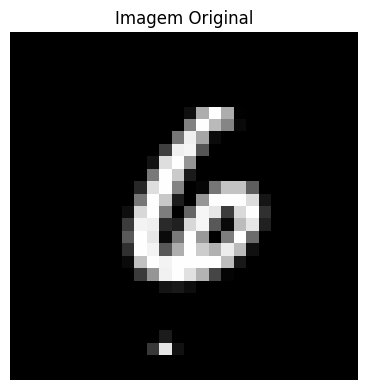

In [ ]:
#Plotar imagens mnist
import numpy as np
import matplotlib.pyplot as plt

imagem_original_mnist = imagem_mnist[1].permute(1, 2, 0)
imagem_original_mnist = np.array(imagem_original_mnist)
labels_mnist = label_mnist[1]
print(imagem_original_mnist.shape)

print(f'Label: {labels_mnist}')

fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

ax1.imshow(imagem_original_mnist, cmap='gray')
ax1.set_title('Imagem Original')
ax1.axis('off')


plt.tight_layout()
plt.show()

Loop de treino: MNIST

In [ ]:
# Um dicionário de hiperparâmetros é uma forma de organizar parâmetros do seu experimento.
# Você pode adicionar mais parâmetros, experimente muda-los!
hyperparameters_mnist = {
    "batch_size": 32,
    "learning_rate": 0.001,
    "kernel_size1": 7,  # exemplo de hiperparâmetro para CNN customizada
    "kernel_size2": 3,  # exemplo de hiperparâmetro para CNN customizada
    "nin": 1, # exemplo para entrada com 3 canais RGB
    "nout": 10,  # exemplo para 10 classes de saída
    "nkernel1": 8, # exemplo para numero de kernels na primeira camada convolucional
    "nkernel2": 32, # exemplo para numero de kernels na segunda camada convolucional
    "padding": 3,
    "stride": 2
}

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 10
n_out = hyperparameters_mnist["nout"]

#inicializa modelo
model_mnist = MyCNN(hyperparameters_mnist, bias=True)
model_mnist.to(device)

#inicializar o otimizador
otimizador = torch.optim.Adam(model_mnist.parameters(), lr=hyperparameters_mnist["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out).to(device)

loss_treino_mnist = []
loss_valid_mnist = []
acc_valid_epoca_mnist = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model_mnist.train()
  with trange(len(train_dataloader_mnist), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader_mnist):
      x, label = batch
      x = x.to(device)
      label = label.to(device)

      #PASSO 1: forward
      y = model_mnist(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader_mnist) #loss por epoca
    loss_treino_mnist.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader_mnist), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model_mnist.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader_mnist):
        x, label = batch
        x = x.to(device)
        label = label.to(device)

        #PASSO 1: forward
        y = model_mnist(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader_mnist) #loss por epoca
      loss_valid_mnist.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader_mnist)
      acc_valid_epoca_mnist.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:02<00:00, 130.71it/s, desc=[Epoca 10] Loss: 0.0000 Acc: 1.0000]


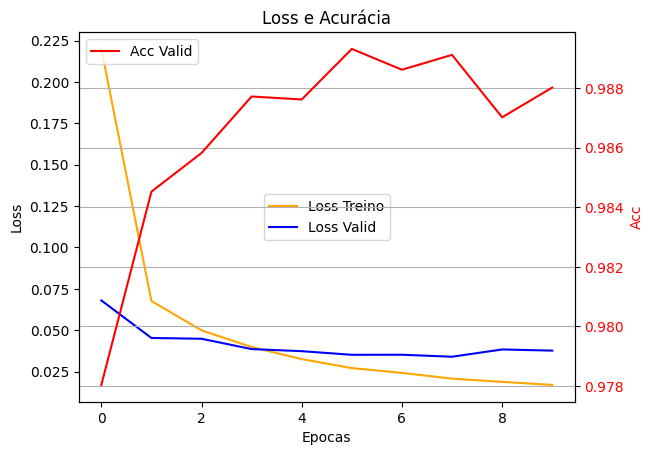

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino_mnist, 'orange', label= "Loss Treino")
ax1.plot(loss_valid_mnist, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca_mnist, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

In [ ]:
np.mean(acc_valid_epoca_mnist)

np.float64(0.9865814566612243)

In [ ]:
acc_valid_epoca_mnist

[0.9780351519584656,
 0.9845247268676758,
 0.9858226776123047,
 0.9877196550369263,
 0.9876198172569275,
 0.9893170595169067,
 0.9886181950569153,
 0.9891173839569092,
 0.98702073097229,
 0.9880191683769226]

CIFAR10

In [ ]:
import torchvision

class CIFAR(torch.utils.data.Dataset):
    def __init__(self, normalize=False, train=False):
        super().__init__()

        self.base_dataset = torchvision.datasets.CIFAR10(root='./data', train=train, download=True)
        self.normalize = normalize

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem do MNIST para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image, label = self.base_dataset[idx]
        image = image.convert("RGB")
        image = np.array(image, dtype=np.float32)
        if self.normalize:
            image = self.min_max(image)

        # Formato PyTorch [Rows, Cols, Channels] --> [Channels, Rows, Cols]
        image = torch.from_numpy(image).float().permute(2, 0, 1)

        return image, label

    def min_max(self, array):
        array = np.array(array)
        return (array - array.min()) / (array.max() - array.min())

In [ ]:
class DataModuleCIFAR(pl.LightningDataModule):
    def __init__(self, hparams):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

    def setup(self, stage=None):
        self.train = CIFAR(train=True, normalize=True)
        self.val = CIFAR(train=False, normalize=True)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)

# Inicialize o Dataloader, e visualize se os dados que vão entrar na rede fazem sentido!

In [ ]:
# TODO visualize o batch com o dataloader

datamodule_cifar = DataModuleCIFAR(hyperparameters)
datamodule_cifar.setup()

train_dataloader_cifar = datamodule_cifar.train_dataloader()
val_dataloader_cifar = datamodule_cifar.val_dataloader()

#visualiza o primeiro batch

primeiro_batch_cifar = next(iter(train_dataloader_cifar))
imagem_cifar, label_cifar= primeiro_batch_cifar
print(f"Imagem Original: {imagem_cifar.shape} --- Label: {label_cifar.shape}")
print("input max:", imagem_cifar.abs().max())
print("input min:", imagem_cifar.min())

100%|██████████| 170M/170M [09:51<00:00, 288kB/s]


Imagem Original: torch.Size([32, 3, 32, 32]) --- Label: torch.Size([32])
input max: tensor(1.)
input min: tensor(0.)


(32, 32, 3)
Label: 1


/tmp/ipykernel_474/3098137766.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  imagem_original_cifar = np.array(imagem_original_cifar)


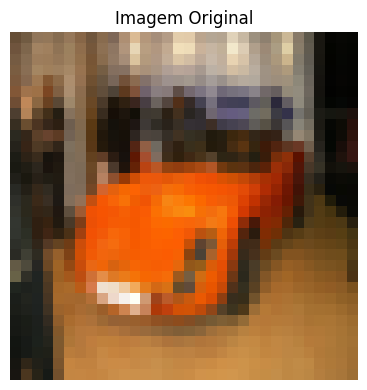

In [ ]:
#Plotar imagens CIFAR
import numpy as np
import matplotlib.pyplot as plt

imagem_original_cifar = imagem_cifar[1].permute(1, 2, 0)
imagem_original_cifar = np.array(imagem_original_cifar)
labels_cifar = label_cifar[1]
print(imagem_original_cifar.shape)

print(f'Label: {labels_cifar}')

fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

ax1.imshow(imagem_original_cifar)
ax1.set_title('Imagem Original')
ax1.axis('off')


plt.tight_layout()
plt.show()

## Loop de Treino: Re-use seu loop de treino do exercício anterior.


In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 40
n_out = hyperparameters["nout"]

#inicializa modelo
model_cifar = MyCNN(hyperparameters, bias=True)
model_cifar.to(device)

#inicializar o otimizador
otimizador = torch.optim.Adam(model_cifar.parameters(), lr=hyperparameters["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out).to(device)

loss_treino_cifar = []
loss_valid_cifar = []
acc_valid_epoca_cifar = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model_cifar.train()
  with trange(len(train_dataloader_cifar), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader_cifar):
      x, label = batch
      x = x.to(device)
      label = label.to(device)

      #PASSO 1: forward
      y = model_cifar(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader_cifar) #loss por epoca
    loss_treino_cifar.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader_cifar), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model_cifar.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader_cifar):
        x, label = batch
        x = x.to(device)
        label = label.to(device)

        #PASSO 1: forward
        y = model_cifar(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader_cifar) #loss por epoca
      loss_valid_cifar.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader_cifar)
      acc_valid_epoca_cifar.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:03<00:00, 99.22it/s, desc=[Epoca 40] Loss: 0.9704 Acc: 0.5625] 


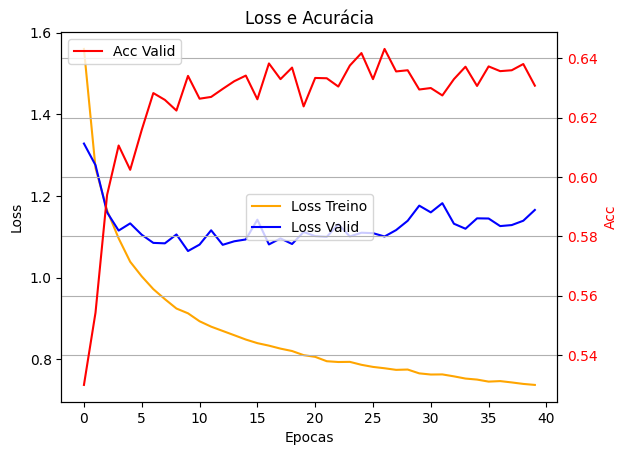

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino_cifar, 'orange', label= "Loss Treino")
ax1.plot(loss_valid_cifar, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca_cifar, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

In [ ]:
np.mean(acc_valid_epoca_cifar)

np.float64(0.6253893613815308)

In [ ]:
acc_valid_epoca_cifar

[0.5299520492553711,
 0.554313063621521,
 0.5939496755599976,
 0.6106230020523071,
 0.6024360656738281,
 0.615914523601532,
 0.6282947063446045,
 0.6259983777999878,
 0.622404158115387,
 0.634085476398468,
 0.6263977289199829,
 0.6269968152046204,
 0.6296924948692322,
 0.6322883367538452,
 0.6341853141784668,
 0.6261980533599854,
 0.6382787227630615,
 0.6329872012138367,
 0.6368809938430786,
 0.6238018870353699,
 0.6333865523338318,
 0.633286714553833,
 0.6304911971092224,
 0.6375798583030701,
 0.6417731642723083,
 0.6329872012138367,
 0.6431708931922913,
 0.6355830430984497,
 0.6359823942184448,
 0.6294928193092346,
 0.6299920082092285,
 0.6274960041046143,
 0.6329872012138367,
 0.637180507183075,
 0.63069087266922,
 0.6372803449630737,
 0.6356828808784485,
 0.6359823942184448,
 0.638079047203064,
 0.6307907104492188]

# DESAFIO: Implemente o dataset TinyImageNet e experimente com sua CNN nele.

O **Tiny ImageNet-200** é um subconjunto reduzido do ImageNet (ILSVRC), criado originalmente para o curso **CS231n (Stanford)**.


* **Total de Classes:** 200
* **Resolução das Imagens:** $64 \times 64$ pixels (RGB).
* **Total de Imagens:** 120.000 imagens divididas em:
  * **Treino (`train`):** 100.000 imagens (500 imagens por classe).
  * **Validação (`val`):** 10.000 imagens (50 imagens por classe).
  * **Teste (`test`):** 10.000 imagens (50 imagens por classe, sem rótulos públicos).

---------------------------------------

* Utilize o código abaixo que visualiza um exemplo aleatório do dataset como base para criar sua classe Dataset! Não utilize torchvision.datasets ou hugging face para modelar o dataset.

* Treine no split de treino e reporte acurácia de validação.




In [ ]:
# Download do dataset
!wget http://cs231n.stanford.edu/tiny-imagenet-200.zip

--2026-09-06 15:51:01--  http://cs231n.stanford.edu/tiny-imagenet-200.zip
Resolving cs231n.stanford.edu (cs231n.stanford.edu)... 171.64.64.64
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://cs231n.stanford.edu/tiny-imagenet-200.zip [following]
--2026-09-06 15:51:01--  https://cs231n.stanford.edu/tiny-imagenet-200.zip
Connecting to cs231n.stanford.edu (cs231n.stanford.edu)|171.64.64.64|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 248100043 (237M) [application/zip]
Saving to: ‘tiny-imagenet-200.zip’

tiny-imagenet-200.z 100%[===================>] 236.61M  76.9MB/s    in 3.1s    

2026-09-06 15:51:05 (76.9 MB/s) - ‘tiny-imagenet-200.zip’ saved [248100043/248100043]



In [ ]:
!unzip ./tiny-imagenet-200.zip

A saída de streaming foi truncada nas últimas 5000 linhas.
  inflating: tiny-imagenet-200/val/images/val_3979.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3963.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7199.JPEG  
  inflating: tiny-imagenet-200/val/images/val_2752.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9687.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9407.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3603.JPEG  
  inflating: tiny-imagenet-200/val/images/val_3412.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6982.JPEG  
  inflating: tiny-imagenet-200/val/images/val_8496.JPEG  
  inflating: tiny-imagenet-200/val/images/val_7332.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9241.JPEG  
  inflating: tiny-imagenet-200/val/images/val_4196.JPEG  
  inflating: tiny-imagenet-200/val/images/val_5980.JPEG  
  inflating: tiny-imagenet-200/val/images/val_6697.JPEG  
  inflating: tiny-imagenet-200/val/images/val_9969.JPEG  
  inflating: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import random
import os
import glob
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torchmetrics import Accuracy


In [ ]:
classes = [os.path.basename(path) for path in glob.glob("tiny-imagenet-200/train/*")]

In [ ]:
class_name_file = [line.split("\t") for line in open(os.path.join("tiny-imagenet-200", "words.txt"), 'r').readlines()]

In [ ]:
class_names_dict = {line[0]: line[1].split(',')[0].strip() for line in class_name_file}

In [ ]:
images = list(glob.iglob("tiny-imagenet-200/train/**/images/*.JPEG", recursive=True))

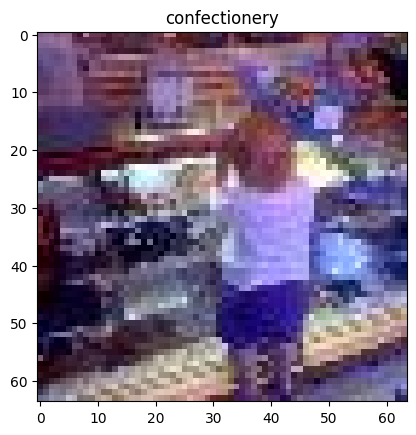

In [ ]:
image_sample = random.choice(images)
target_name = os.path.basename(image_sample.split("/images")[0])
plt.imshow(Image.open(image_sample))
plt.title(class_names_dict[target_name])
plt.show()

### Dataset TinyImageNet

In [ ]:
# Um dicionário de hiperparâmetros é uma forma de organizar parâmetros do seu experimento.
# Você pode adicionar mais parâmetros, experimente muda-los!
hyperparameters_tiny = {
    "batch_size": 32,
    "learning_rate": 0.001,
    "kernel_size1": 7,  # exemplo de hiperparâmetro para CNN customizada
    "kernel_size2": 3,  # exemplo de hiperparâmetro para CNN customizada
    "nin": 3,           # exemplo para entrada com 3 canais RGB
    "nout": 200,        # exemplo para 10 classes de saída
    "nkernel1": 8,      # exemplo para numero de kernels na primeira camada convolucional --> 8
    "nkernel2": 32,     # exemplo para numero de kernels na segunda camada convolucional --> 32
    "padding": 3,
    "stride": 2
}

In [ ]:
import torchvision
import os
import torch

class TinyImageNet(torch.utils.data.Dataset):
    def __init__(self, caminho_arquivo, normalize=False, train=False):
        super().__init__()
        self.normalize = normalize
        self.train = train

        #faz download e deszipa
        if os.path.exists(caminho_arquivo):
          print('O arquivo está baixado e disponível!')
        else:
          print('O arquivo ainda não foi baixado ou não existe.')
          print('Baixando...')
          !wget http://cs231n.stanford.edu/tiny-imagenet-200.zip
          print('Descompactando...')
          !unzip ./tiny-imagenet-200.zip

        #organizando os dados
        if self.train == True:
          nome = "tiny-imagenet-200/train/"
        else:
          nome = "tiny-imagenet-200/val/"
          nome_label = "val_annotations.txt"
          pasta = "tiny-imagenet-200/val"
          class_name_file_val = [line.split("\t") for line in open(os.path.join(pasta, nome_label), 'r').readlines()]
          self.class_names_dict_val = {line[0]: line[1].split(',')[0].strip() for line in class_name_file_val}

        #classes presentes no TinyImageNet
        self.classes = sorted(os.path.basename(path) for path in glob.glob("tiny-imagenet-200/train/*"))
        class_name_file = [line.split("\t") for line in open(os.path.join("tiny-imagenet-200", "words.txt"), 'r').readlines()]

        #associa nome com label string
        self.class_names_dict = {line[0]: line[1].split(',')[0].strip() for line in class_name_file}

        #associa nome com label numerica
        self.class_to_idx = {class_name: idx for idx, class_name in enumerate(self.classes)}

        #as imagens propriamente ditas
        self.base_dataset = list(glob.iglob(nome + "**/images/*.JPEG", recursive=True))


    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        """Retorna (image: np.ndarray, label: int).

        - Converta a imagem para np.ndarray float.
        - Se self.normalize, aplique a normalização min-max para [0, 1] (Exercício 3.1)
        """
        image_nome = self.base_dataset[idx]
        image = Image.open(image_nome).convert('RGB') #garante que todas as imagens de fato terão 3 canais
        image = np.array(image, dtype=np.float32)

        if self.normalize:
            image = self.min_max(image)

        # Formato PyTorch [Rows, Cols, Channels] --> [Channels, Rows, Cols]
        image = torch.from_numpy(image).float().permute(2, 0, 1)

        #identificando a correta label no dicionario
        if self.train == True:
          target_name = os.path.basename(image_nome.split("/images")[0])
        else:
          target_name = self.class_names_dict_val[image_nome.split('/')[-1]]

        label = self.class_to_idx[target_name]              #index do label
        label_string = self.class_names_dict[target_name]   #label string

        return image, label, label_string

    def min_max(self, array):
        array = np.array(array)
        return (array - array.min()) / (array.max() - array.min())

In [ ]:
class DataModuleTiny(pl.LightningDataModule):
    def __init__(self, hparams, caminho_arquivo):
        super().__init__()

        # O PyTorch Lightning possui funções para facilitar o uso, log e recuperação de hiperparâmetros
        self.save_hyperparameters(hparams)

        self.caminho_arquivo = caminho_arquivo

    def setup(self, stage=None):
        self.train = TinyImageNet(self.caminho_arquivo, train=True, normalize=True)
        self.val = TinyImageNet(self.caminho_arquivo, train=False, normalize=True)

    def train_dataloader(self):
        return DataLoader(self.train,
                          batch_size=self.hparams.batch_size,  # note o uso do hiperparâmetro configurável
                          shuffle=True)

    def val_dataloader(self):
        return DataLoader(self.val,
                          batch_size=self.hparams.batch_size,
                          shuffle=False)

In [ ]:
# TODO visualize o batch com o dataloader
caminho_arquivo = "tiny-imagenet-200"
datamodule_tiny = DataModuleTiny(hyperparameters_tiny, caminho_arquivo)
datamodule_tiny.setup()

train_dataloader_tiny = datamodule_tiny.train_dataloader()
val_dataloader_tiny = datamodule_tiny.val_dataloader()

#visualiza o primeiro batch

primeiro_batch_tiny = next(iter(val_dataloader_tiny))
imagem_tiny, label, label_string= primeiro_batch_tiny
print(f"Imagem Original: {imagem_tiny.shape} --- Label: {len(label)}")
print("input max:", imagem_tiny.abs().max())
print("input min:", imagem_tiny.min())

O arquivo está baixado e disponível!
O arquivo está baixado e disponível!
Imagem Original: torch.Size([32, 3, 64, 64]) --- Label: 32
input max: tensor(1.)
input min: tensor(0.)


(64, 64, 3)
Label: 7 = scorpion


/tmp/ipykernel_1009/2874364668.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  imagem_original_tiny = np.array(imagem_original_tiny)


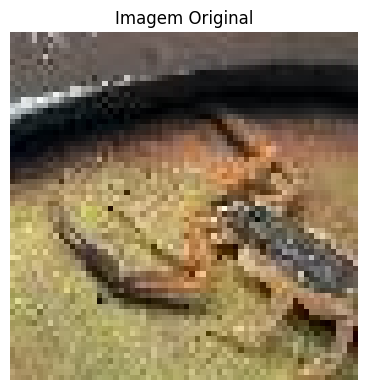

In [ ]:
#Plotar imagens Tiny
import numpy as np
import matplotlib.pyplot as plt

imagem_original_tiny = imagem_tiny[3].permute(1, 2, 0)
imagem_original_tiny = np.array(imagem_original_tiny)
labels_tiny = label[3]
print(imagem_original_tiny.shape)

print(f'Label: {labels_tiny} = {label_string[3]}')

fig, ax1 = plt.subplots(1, 1, figsize=(8, 4))

ax1.imshow(imagem_original_tiny)
ax1.set_title('Imagem Original')
ax1.axis('off')


plt.tight_layout()
plt.show()

### Loop Treino

In [ ]:
# TODO
from tqdm import trange
from torchmetrics import Accuracy

epocas = 10
n_out = hyperparameters_tiny["nout"]

#inicializa modelo
model_tiny = MyCNN(hyperparameters_tiny, bias=True)
model_tiny.to(device)

#inicializar o otimizador
otimizador = torch.optim.Adam(model_tiny.parameters(), lr=hyperparameters_tiny["learning_rate"])

#inicializar loss
cross_entropia = MyCrossEntropyLoss(n_out)

#inicializar metrica
acc = Accuracy(task="multiclass", num_classes=n_out).to(device)

loss_treino_tiny = []
loss_valid_tiny = []
acc_valid_epoca_tiny = []

for epoca in range(epocas):
  loss_batch_treino = 0
  loss_batch_valid = 0
  acc_soma = 0

  ################### LOOP TREINO #####################
  model_tiny.train()
  with trange(len(train_dataloader_tiny), desc='Loop Treino') as progress_bar:
    for batch_idx, batch in zip(progress_bar, train_dataloader_tiny):
      x, label, _ = batch
      x = x.to(device)
      label = label.to(device)

      #PASSO 1: forward
      y = model_tiny(x)

      loss = cross_entropia(y, label)
      acc_train = acc(y, label)
      loss_batch_treino = loss + loss_batch_treino
      progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_train:.4f}"))


      #PASSO2: backpropagation
      loss.backward()
      otimizador.step()      #atualiza os pesos do modelo usando o otimizador
      otimizador.zero_grad() #reseta os gradientes

    loss_epoca = loss_batch_treino/len(train_dataloader_tiny) #loss por epoca
    loss_treino_tiny.append(loss_epoca.item())


  ###################### LOOP VALIDAÇÃO ######################
  #não atualiza mais nada
  with trange(len(val_dataloader_tiny), desc='Loop Valid') as progress_bar:
    with torch.no_grad():
      model_tiny.eval()
      for batch_idx, batch in zip(progress_bar, val_dataloader_tiny):
        x, label, _ = batch
        x = x.to(device)
        label = label.to(device)

        #PASSO 1: forward
        y = model_tiny(x)

        loss = cross_entropia(y, label)
        acc_valid = acc(y, label)
        loss_batch_valid = loss + loss_batch_valid
        acc_soma = acc_valid + acc_soma
        progress_bar.set_postfix(desc=(f"[Epoca {epoca + 1}] Loss: {loss.item():.4f} Acc: {acc_valid:.4f}"))

      loss_epoca_valid = loss_batch_valid/len(val_dataloader_tiny) #loss por epoca
      loss_valid_tiny.append(loss_epoca_valid.item())
      acc_final = acc_soma/len(val_dataloader_tiny)
      acc_valid_epoca_tiny.append(acc_final.item())

Loop Valid: 100%|██████████| 313/313 [00:07<00:00, 44.01it/s, desc=[Epoca 10] Loss: 4.3046 Acc: 0.1250]


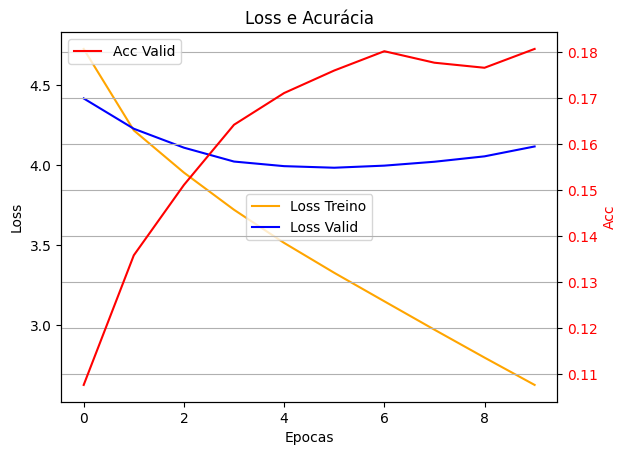

In [ ]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()

# Plotando a primeira série de dados no primeiro eixo (ax1)
ax1.plot(loss_treino_tiny, 'orange', label= "Loss Treino")
ax1.plot(loss_valid_tiny, 'blue', label= "Loss Valid")
ax1.legend(loc='center')
ax1.set_xlabel("Epocas")
ax1.set_ylabel("Loss", color="black")
ax1.tick_params(axis="y", labelcolor="black")

# Criando o segundo eixo Y que compartilha o mesmo eixo X
ax2 = ax1.twinx()

# Plotando a segunda série de dados no segundo eixo (ax2)
ax2.plot(acc_valid_epoca_tiny, 'red', label= "Acc Valid")
ax2.legend()
ax2.set_ylabel("Acc", color="red")
ax2.tick_params(axis="y", labelcolor="red")

# Exibindo o gráfico
plt.title("Loss e Acurácia")
plt.grid()
plt.show()

In [ ]:
np.mean(acc_valid_epoca_tiny)

np.float64(0.16214057356119155)

In [ ]:
acc_valid_epoca_tiny

[0.10772763192653656,
 0.13588258624076843,
 0.1511581391096115,
 0.16423721611499786,
 0.17112620174884796,
 0.1760183721780777,
 0.18021166324615479,
 0.17771565914154053,
 0.17661741375923157,
 0.18071085214614868]